In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
df=pd.read_csv('Social_Network_ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.drop(columns=["User ID"], inplace=True)
df["Gender"] = df["Gender"].map({"Male": 1, "Female":0})
df

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0
...,...,...,...,...
395,0,46,41000,1
396,1,51,23000,1
397,0,50,20000,1
398,1,36,33000,0


In [5]:
x = df[["Gender", "Age", "EstimatedSalary"]]
y = df["Purchased"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42)

In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(x_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8875

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[50,  2],
       [ 7, 21]])

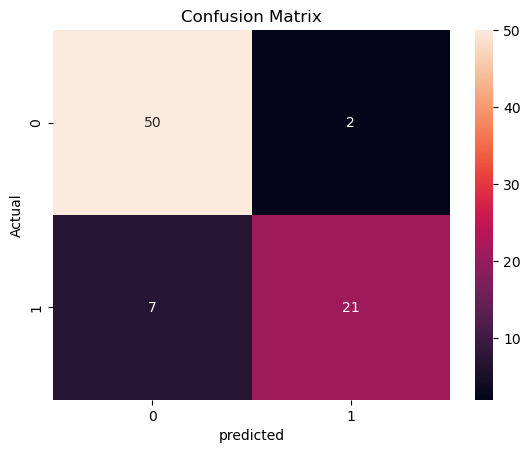

In [13]:
sns.heatmap(conf_matrix, annot=True)
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
new_data = np.array([[1, 30, 80000]])
new_data_df = pd.DataFrame(new_data, columns = x.columns)
new_data_scaled = scaler.transform(new_data_df)
prediction = model.predict(new_data_scaled)
if prediction == 1:
    print("Purchase Prediction: Yes")
else:
    print("Purcahse Prediction: No")

Purcahse Prediction: No
